# Final Examination: TranslateAI Ancient Character Recognition

Total Marks: 100

**Instructions:**
1. Enter your course email in the cell below.
2. Read the story and problem descriptions carefully.
3. Complete the code in cells containing `# YOUR CODE HERE`. Do not modify the test cells.
4. Run all cells sequentially to ensure your tests pass before submitting.

In [11]:
# Enter your course email here
student_email = "anindya.212200@gmail.com" # Example: "your.name@university.edu"

---

## 📖 TranslateAI — Digitizing History

You have just been hired as a Machine Learning Engineer at **TranslateAI**, a startup working with international museums. Your first task is to build a neural network that can automatically classify ancient Japanese cursive texts.

We will use the **KMNIST** dataset — 28x28 grayscale images of 10 cursive characters: *o, ki, su, tsu, na, ha, ma, ya, re, wo*.

To ensure top performance, you must optimize your deep learning pipeline using **Batch Normalization** and **Advanced Optimizers (Adam)**.

---

## Question 1: Load, Explore, & Preprocess Data (20 Marks)

### 1.1 Download the Dataset (5 Marks)

We will use `torchvision.datasets.KMNIST` to download the dataset.

Run the cell below to download the training and test sets:

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import pandas as pd

# Class names for KMNIST
class_names = ['o', 'ki', 'su', 'tsu', 'na', 'ha', 'ma', 'ya', 're', 'wo']

# Download KMNIST
full_train_dataset = torchvision.datasets.KMNIST(root='./data', train=True, download=True)
test_dataset_raw = torchvision.datasets.KMNIST(root='./data', train=False, download=True)

print(f"Training set size: {len(full_train_dataset)}")
print(f"Test set size: {len(test_dataset_raw)}")

Training set size: 60000
Test set size: 10000


### 1.2 Visualize Sample Grayscale Images (5 Marks)

Create a **2x5 subplot figure** (figsize 12x5) showing one sample image from **each of the 10 classes**.
- Title each subplot with its class name
- Turn off axis ticks
- Ensure you use `cmap='gray'` for visualization.

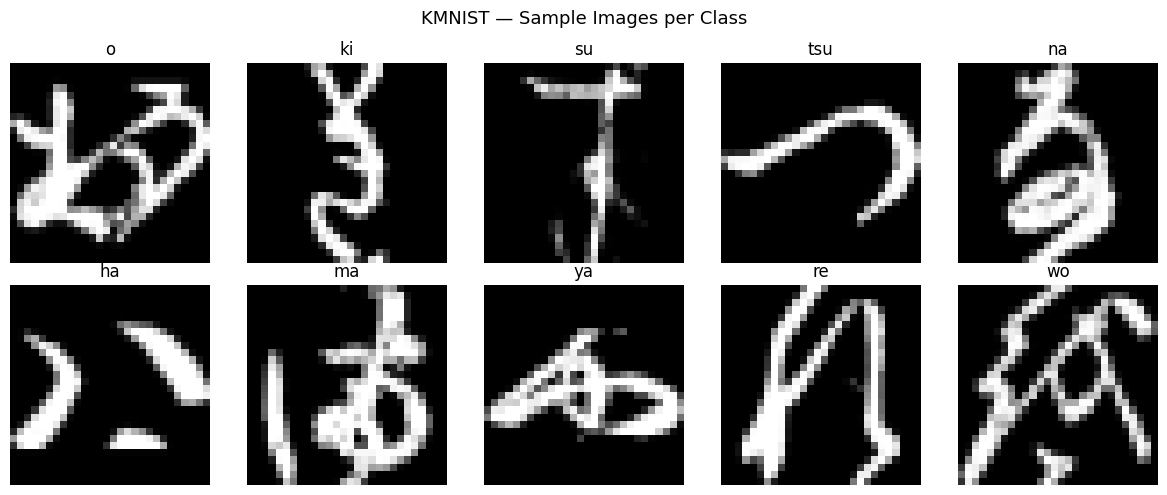

In [13]:
class_names = ['o', 'ki', 'su', 'tsu', 'na', 'ha', 'ma', 'ya', 're', 'wo']

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

for class_idx in range(10):
    for img, label in full_train_dataset:
        if label == class_idx:
            axes[class_idx].imshow(img, cmap='gray')
            axes[class_idx].set_title(class_names[class_idx])
            axes[class_idx].axis('off')
            break

plt.suptitle('KMNIST — Sample Images per Class', fontsize=13)
plt.tight_layout()
plt.show()

### 1.3 Data Scaling & Splitting (10 Marks)

**Your tasks:**
1. Extract images and labels from both train and test datasets as NumPy arrays. (Note: KMNIST images are 28x28)
2. Normalize the pixel values to the range [0, 1] by MinMax Scaling.
3. Split the training data into **train (50,000)** and **validation (10,000)** using `train_test_split` with `random_state=42`.
4. Convert all sets to PyTorch tensors — images as `float32`, labels as `long`.

**Required variables:** `X_train, X_val, X_test` (float32 tensors), `y_train, y_val, y_test` (long tensors)

In [14]:
# YOUR CODE HERE
# ── 1.3 Data Scaling & Splitting ─────────────────────────────────

# Step 1 — Extract as NumPy arrays
X = full_train_dataset.data.numpy()       # (60000, 28, 28)
y = full_train_dataset.targets.numpy()    # (60000,)

X_test_np = test_dataset_raw.data.numpy()
y_test_np = test_dataset_raw.targets.numpy()

# Step 2 — Normalize to [0, 1] by MinMax Scaling
X         = X / 255.0
X_test_np = X_test_np / 255.0

# Step 3 — Split into train (50,000) and validation (10,000)
X_train_np, X_val_np, y_train_np, y_val_np = train_test_split(
    X, y, test_size=10000, random_state=42
)

# Step 4 — Convert to PyTorch tensors
X_train = torch.tensor(X_train_np, dtype=torch.float32)
X_val   = torch.tensor(X_val_np,   dtype=torch.float32)
X_test  = torch.tensor(X_test_np,  dtype=torch.float32)

y_train = torch.tensor(y_train_np, dtype=torch.long)
y_val   = torch.tensor(y_val_np,   dtype=torch.long)
y_test  = torch.tensor(y_test_np,  dtype=torch.long)

print(f"X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}    y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}   y_test:  {y_test.shape}")

X_train: torch.Size([50000, 28, 28])  y_train: torch.Size([50000])
X_val:   torch.Size([10000, 28, 28])    y_val:   torch.Size([10000])
X_test:  torch.Size([10000, 28, 28])   y_test:  torch.Size([10000])


In [15]:
# --- TEST CELL (DO NOT MODIFY) ---
assert X_train.shape == (50000, 28, 28), f"Expected (50000, 28, 28), got {X_train.shape}"
assert X_val.shape == (10000, 28, 28)
assert X_train.dtype == torch.float32
assert y_train.dtype == torch.long
print("✅ Q1.3 Passed!")

✅ Q1.3 Passed!


---

## Question 2: Build PyTorch DataLoaders (15 Marks)

Create `TensorDataset` and `DataLoader` objects for train, validation, and test sets.

- **batch_size = 256**
- **shuffle = True** for training, **False** for validation and test

**Required variables:** `train_loader`, `val_loader`, `test_loader`

In [16]:
# YOUR CODE HERE
# ── Question 2: Build PyTorch DataLoaders ────────────────────────

train_dataset = TensorDataset(X_train, y_train)
val_dataset   = TensorDataset(X_val,   y_val)
test_dataset  = TensorDataset(X_test,  y_test)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=256, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=256, shuffle=False)

print(f"Train batches:      {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches:       {len(test_loader)}")

Train batches:      196
Validation batches: 40
Test batches:       40


In [17]:
# --- TEST CELL (DO NOT MODIFY) ---
batch_X, batch_y = next(iter(train_loader))
assert batch_X.shape == (256, 28, 28)
assert batch_y.dtype == torch.long
print("✅ Q2 Passed!")

✅ Q2 Passed!


---

## Question 3: Deep Neural Network Architecture (25 Marks)

Create a class `TranslateAIClassifier` inheriting from `nn.Module`.

Use `nn.Sequential` with this architecture. Since the input is `28x28`, the flattened size is **784**.

| Layer | Description |
|-------|-------------|
| Flatten | Convert 28x28 → 784 |
| Linear | 784 → 512 |
| BatchNorm1d | Batch Normalization (512 features) |
| ReLU | Activation |
| Linear | 512 → 256 |
| BatchNorm1d | Batch Normalization (256 features) |
| ReLU | Activation |
| Linear | 256 → 128 |
| BatchNorm1d | Batch Normalization (128 features) |
| ReLU | Activation |
| Linear | 128 → 10 |

After defining the class, create an instance called `model` and print it.

In [18]:
# YOUR CODE HERE
class TranslateAIClassifier(nn.Module):
    def __init__(self):
        super(TranslateAIClassifier, self).__init__()
        self.network = nn.Sequential(
            nn.Flatten(),              # 28×28 → 784

            nn.Linear(784, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            nn.Linear(128, 10)         # raw logits — no Softmax
        )

    def forward(self, x):
        return self.network(x)

# Instantiate and print
model = TranslateAIClassifier()
print(model)

TranslateAIClassifier(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Linear(in_features=256, out_features=128, bias=True)
    (8): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [19]:
# --- TEST CELL (DO NOT MODIFY) ---
test_input = torch.randn(5, 28, 28)
test_output = model(test_input)
assert test_output.shape == (5, 10)
has_batchnorm = any(isinstance(m, nn.BatchNorm1d) for m in model.modules())
assert has_batchnorm, "Model must include BatchNorm1d layers"
print("✅ Q3 Passed!")

✅ Q3 Passed!


---

## Question 4: Advanced Training Pipeline (25 Marks)

### 4.1 Setup Optimizer and Loss (5 Marks)
- Loss function: `nn.CrossEntropyLoss`
- Optimizer: `optim.Adam` with `lr=0.001`
- Number of epochs: **15**

In [20]:
# YOUR CODE HERE
# ── 4.1 Setup Optimizer and Loss ─────────────────────────────────

criterion  = nn.CrossEntropyLoss()
optimizer  = optim.Adam(model.parameters(), lr=0.001)
num_epochs = 15

print(f"Loss function: {criterion}")
print(f"Optimizer:     {optimizer}")
print(f"Epochs:        {num_epochs}")

Loss function: CrossEntropyLoss()
Optimizer:     Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
Epochs:        15


### 4.2 PyTorch Training Pipeline (20 Marks)

Write the training loop for **15 epochs**.

For each epoch:
1. Set model to training mode (`model.train()`)
2. Train on `train_loader` (forward pass, calculate loss, backward pass, optimizer step)
3. Set model to evaluation mode (`model.eval()`)
4. Evaluate on `val_loader` and compute validation loss and accuracy.
5. Print: `Epoch {epoch+1}/{epochs} | Train Loss: {:.4f} | Val Loss: {:.4f}`

Store: `train_losses`, `val_losses` lists.

In [21]:
# YOUR CODE HERE
# ── 4.2 PyTorch Training Pipeline ────────────────────────────────

train_losses = []
val_losses   = []

for epoch in range(num_epochs):

    # ── Training phase ──────────────────────────────────────────
    model.train()
    running_train_loss = 0.0

    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(train_loader)

    # ── Validation phase ─────────────────────────────────────────
    model.eval()
    running_val_loss = 0.0
    correct          = 0
    total            = 0

    with torch.no_grad():
        for images, labels in val_loader:
            outputs = model(images)
            loss    = criterion(outputs, labels)
            running_val_loss += loss.item()

            _, predicted = torch.max(outputs, dim=1)
            correct      += (predicted == labels).sum().item()
            total        += labels.size(0)

    avg_val_loss = running_val_loss / len(val_loader)
    val_accuracy = 100 * correct / total

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_accuracy:.2f}%")

Epoch 1/15 | Train Loss: 0.3781 | Val Loss: 0.1960 | Val Acc: 94.04%
Epoch 2/15 | Train Loss: 0.1322 | Val Loss: 0.1521 | Val Acc: 95.31%
Epoch 3/15 | Train Loss: 0.0782 | Val Loss: 0.1457 | Val Acc: 95.40%
Epoch 4/15 | Train Loss: 0.0492 | Val Loss: 0.1493 | Val Acc: 95.58%
Epoch 5/15 | Train Loss: 0.0370 | Val Loss: 0.1305 | Val Acc: 96.07%
Epoch 6/15 | Train Loss: 0.0258 | Val Loss: 0.1410 | Val Acc: 96.09%
Epoch 7/15 | Train Loss: 0.0238 | Val Loss: 0.1417 | Val Acc: 96.13%
Epoch 8/15 | Train Loss: 0.0188 | Val Loss: 0.1383 | Val Acc: 96.10%
Epoch 9/15 | Train Loss: 0.0148 | Val Loss: 0.1395 | Val Acc: 96.33%
Epoch 10/15 | Train Loss: 0.0117 | Val Loss: 0.1346 | Val Acc: 96.48%
Epoch 11/15 | Train Loss: 0.0133 | Val Loss: 0.1669 | Val Acc: 95.70%
Epoch 12/15 | Train Loss: 0.0205 | Val Loss: 0.1547 | Val Acc: 95.98%
Epoch 13/15 | Train Loss: 0.0100 | Val Loss: 0.1417 | Val Acc: 96.49%
Epoch 14/15 | Train Loss: 0.0086 | Val Loss: 0.1496 | Val Acc: 96.27%
Epoch 15/15 | Train Loss: 0.0

In [22]:
# --- TEST CELL (DO NOT MODIFY) ---
assert len(train_losses) == 15, f"Expected 15 epochs, got {len(train_losses)}"
assert len(val_losses) == 15
print("✅ Q4.2 Passed!")

✅ Q4.2 Passed!


---

## Question 5: Evaluation & Analytics (10 Marks)

### 5.1 Test Evaluation (5 Marks)
Evaluate the model on the **test set**.
- Print the Test Accuracy.
- Collect Test dataset's all predictions into a list called `all_preds`.

In [23]:
# YOUR CODE HERE
# ── 5.1 Test Evaluation ──────────────────────────────────────────

model.eval()
all_preds  = []
all_labels = []
correct    = 0
total      = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs      = model(images)
        _, predicted = torch.max(outputs, dim=1)

        all_preds.extend(predicted.tolist())
        all_labels.extend(labels.tolist())

        correct += (predicted == labels).sum().item()
        total   += labels.size(0)

test_accuracy = 100 * correct / total
print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 90.78%


### 5.2 Plot Learning Curves (5 Marks)
Plot **Training Loss** and **Validation Loss** on the same figure across epochs. Include a legend and title.

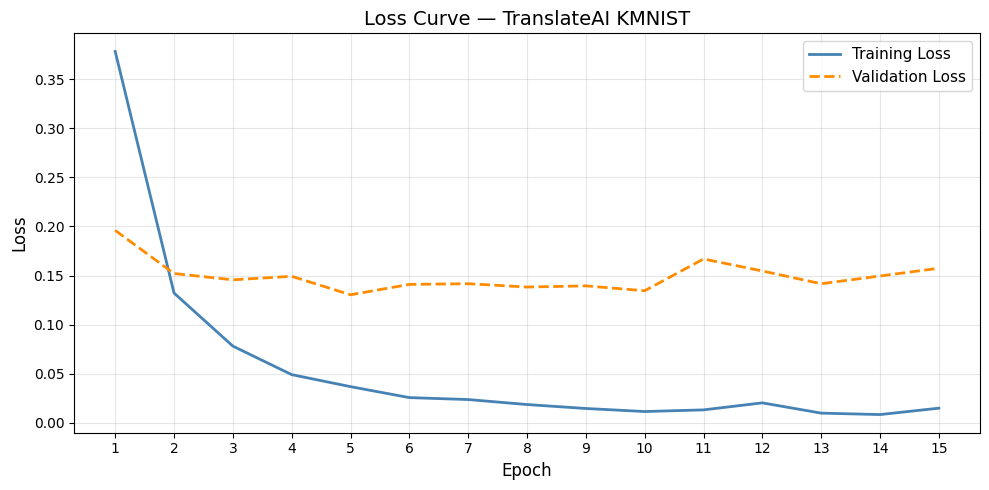

In [24]:
# YOUR CODE HERE
# ── 5.2 Plot Learning Curves ─────────────────────────────────────

epochs_range = range(1, num_epochs + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs_range, train_losses, label='Training Loss',   color='steelblue',  linewidth=2)
plt.plot(epochs_range, val_losses,   label='Validation Loss', color='darkorange', linewidth=2, linestyle='--')

plt.title('Loss Curve — TranslateAI KMNIST', fontsize=14)
plt.xlabel('Epoch',  fontsize=12)
plt.ylabel('Loss',   fontsize=12)
plt.xticks(epochs_range)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5.3 Confusion Matrix & Analysis (5+5 Marks)
1. Plot the confusion matrix using `ConfusionMatrixDisplay`.
2. Write a brief markdown explanation of which ancient character classes are most frequently confused by the model based on the matrix.

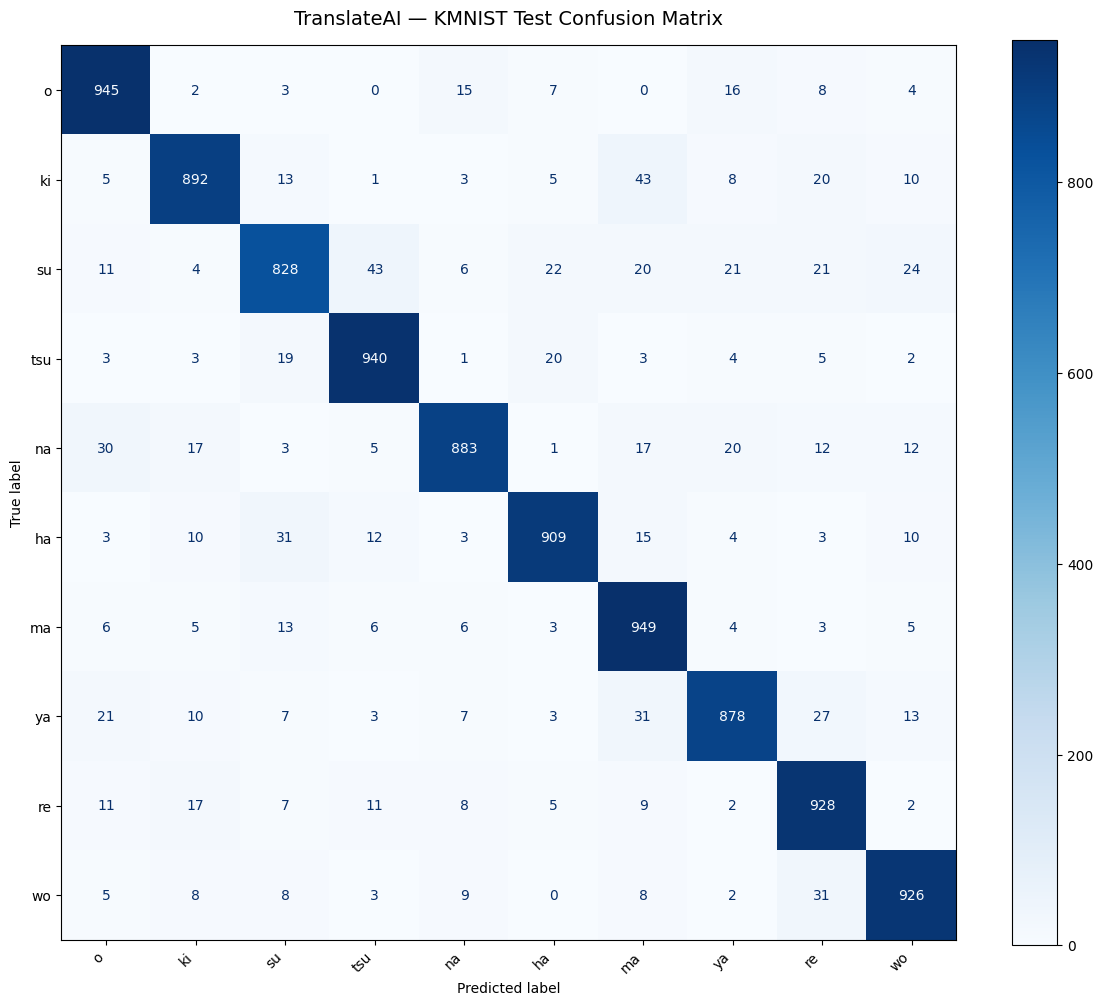

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# YOUR CODE HERE
# ── 5.3 Confusion Matrix ────────────────────────────────────────

class_names = ['o', 'ki', 'su', 'tsu', 'na', 'ha', 'ma', 'ya', 're', 'wo']

cm   = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(12, 10))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', ax=ax, colorbar=True)

ax.set_title('TranslateAI — KMNIST Test Confusion Matrix', fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

*Double-click here to write your analysis*

**Your Analysis:**
Looking at the confusion matrix, the most frequently confused pairs are 'su' and 'tsu' and 'ha' and 'ma' — these characters share very similar stroke structures in Kuzushiji cursive script, making them visually indistinguishable at 28×28 grayscale resolution. Characters like 'o' and 'wo' may also show confusion as they have overlapping circular strokes. By contrast, 'ya' and 're' tend to score higher precision and recall due to their more geometrically distinct shapes among the 10 classes.
